In [7]:
import pandas as pd
import os
import shutil
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix



In [8]:

# Load metadata
tracks = pd.read_csv(
    r'C:\Users\Srikanth\srihome\project\data\fma_metadata\tracks.csv',
    index_col=0, header=[0, 1]
)

# Filter only fma_small tracks
small = tracks[tracks['set', 'subset'] == 'small']

print("Number of tracks in FMA small:", len(small))
print("Genres:")
print(small['track', 'genre_top'].value_counts())

Number of tracks in FMA small: 8000
Genres:
(track, genre_top)
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64


In [9]:
# Load metadata
tracks = pd.read_csv(
    r'C:\Users\Srikanth\srihome\project\data\fma_metadata\tracks.csv',
    index_col=0,
    header=[0, 1]
)

# Keep only FMA small
small = tracks[tracks[('set', 'subset')] == 'small']

# Take 2 tracks from each top-level genre
samples = small.groupby(('track', 'genre_top'), group_keys=False).head(2)

# Paths
audio_root = r'C:\Users\Srikanth\srihome\project\data\fma_small'
output_root = r'C:\Users\Srikanth\srihome\project\data\genre_samples'

os.makedirs(output_root, exist_ok=True)

copied = 0

for track_id, genre in zip(samples.index, samples[('track', 'genre_top')]):
    genre = str(genre).strip().replace('/', '-')
    
    tid = f"{int(track_id):06d}"
    subfolder = tid[:3]
    
    src = os.path.join(audio_root, subfolder, f"{tid}.mp3")
    dest_folder = os.path.join(output_root, genre)
    dest_file = os.path.join(dest_folder, f"{tid}.mp3")
    
    if os.path.exists(src):
        os.makedirs(dest_folder, exist_ok=True)
        shutil.copy(src, dest_file)
        copied += 1
        print(f"Copied: {genre} -> {tid}.mp3")
    else:
        print(f"Missing: {src}")

print(f"\nDone. Copied {copied} files.")

Copied: Hip-Hop -> 000002.mp3
Copied: Hip-Hop -> 000005.mp3
Copied: Pop -> 000010.mp3
Copied: Folk -> 000140.mp3
Copied: Folk -> 000141.mp3
Copied: Experimental -> 000148.mp3
Copied: Rock -> 000182.mp3
Copied: Pop -> 000213.mp3
Copied: Rock -> 000255.mp3
Copied: Experimental -> 000424.mp3
Copied: International -> 000666.mp3
Copied: International -> 000667.mp3
Copied: Electronic -> 001482.mp3
Copied: Electronic -> 003573.mp3
Copied: Instrumental -> 010250.mp3
Copied: Instrumental -> 011638.mp3

Done. Copied 16 files.


In [10]:
small[[('track', 'title'),
       ('track', 'genre_top'),
       ('set',   'subset')]].head()

track              set
                       title genre_top subset
track_id                                     
2                       Food   Hip-Hop  small
5                 This World   Hip-Hop  small
10                   Freeway       Pop  small
140       Queen Of The Wires      Folk  small
141                     Ohio      Folk  small

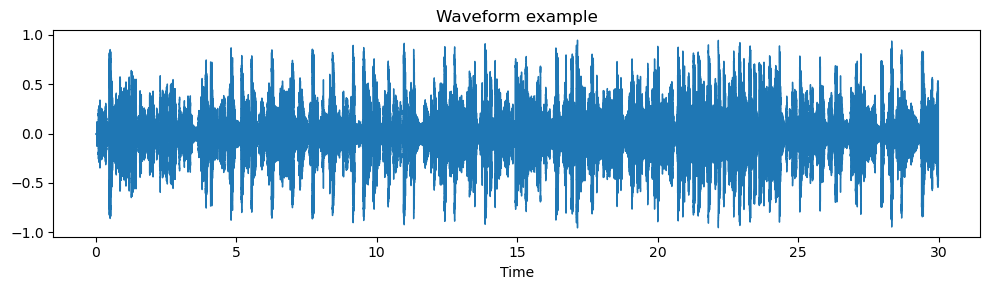

In [11]:
# make wave formm, raw audio signal as a function of time, Where the sound is loud (large peaks) or quiet (near zero).
# shows “volume over time,” but not “which pitches over time”.

file_path = r"C:\Users\Srikanth\srihome\project\data\genre_samples\Hip-Hop\000002.mp3"

y, sr = librosa.load(file_path, sr=22050, mono=True)

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform example")
plt.tight_layout()
plt.show()

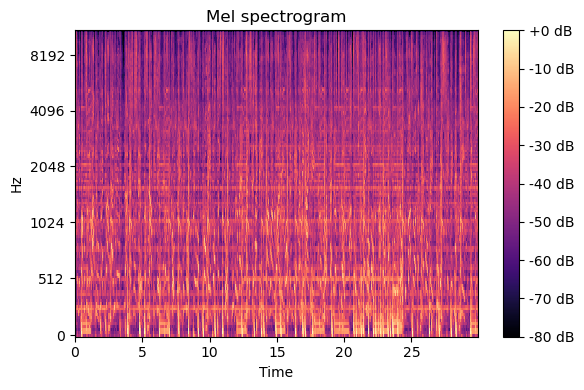

In [12]:
# mel spectogram: Which frequencies are present at each moment in time, and how strong are they? close to human pitch
# intensity in decibls (dB). Bright = strong energy; dark = weak
#Recognize rhythms (vertical stripes) and sustained notes (horizontal bands). 
# Capture the “texture” of a genre: ex: Hip-Hop: strong low‑frequency energy, clear beats.Rock: strong midrange energy from guitars and snare
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(6, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.f dB")
plt.title("Mel spectrogram")
plt.tight_layout()
plt.show()

In [13]:
import warnings
warnings.filterwarnings('ignore')

def extract_mfcc(file_path, sr=22050, n_mfcc=13):
    try:
        y, sr = librosa.load(file_path, sr=sr, mono=True)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return mfcc.mean(axis=1)
    except Exception as e:
        return None  # skip corrupt or unreadable files

In [14]:
import warnings
warnings.filterwarnings('ignore')

audio_root = r"C:\Users\Srikanth\srihome\project\data\fma_small"

def build_split_features(small_df):
    X_train, y_train = [], []
    X_valid, y_valid = [], []
    X_test,  y_test  = [], []

    total = len(small_df)
    skipped = 0

    for i, (track_id, row) in enumerate(small_df.iterrows()):
        tid = f"{int(track_id):06d}"
        subfolder = tid[:3]
        file_path = os.path.join(audio_root, subfolder, f"{tid}.mp3")

        if not os.path.exists(file_path):
            skipped += 1
            continue

        split = row[('set', 'split')]
        genre = row[('track', 'genre_top')]

        feat = extract_mfcc(file_path)

        # skip if file was corrupt (extract_mfcc returned Nne)
        if feat is None:
            skipped += 1
            continue

        if split == 'training':
            X_train.append(feat)
            y_train.append(genre)
        elif split == 'validation':
            X_valid.append(feat)
            y_valid.append(genre)
        elif split == 'test':
            X_test.append(feat)
            y_test.append(genre)

        if (i + 1) % 500 == 0:
            print(f"processed {i + 1} / {total} | skipped so far: {skipped}")

    print(f"\nDone. Total skipped (missing + corrupt): {skipped}")

    X_train, y_train = np.array(X_train), np.array(y_train)
    X_valid, y_valid = np.array(X_valid), np.array(y_valid)
    X_test,  y_test  = np.array(X_test),  np.array(y_test)

    return X_train, y_train, X_valid, y_valid, X_test, y_test


X_train, y_train, X_valid, y_valid, X_test, y_test = build_split_features(small)

print("Train:", X_train.shape, "| genres:", np.unique(y_train))
print("Valid:", X_valid.shape, "| genres:", np.unique(y_valid))
print("Test: ", X_test.shape,  "| genres:", np.unique(y_test))

processed 500 / 8000 | skipped so far: 0
processed 1000 / 8000 | skipped so far: 0
processed 1500 / 8000 | skipped so far: 0
processed 2000 / 8000 | skipped so far: 0
processed 2500 / 8000 | skipped so far: 0
processed 3000 / 8000 | skipped so far: 0
processed 3500 / 8000 | skipped so far: 0
processed 4000 / 8000 | skipped so far: 0
processed 4500 / 8000 | skipped so far: 1
processed 5000 / 8000 | skipped so far: 2
processed 5500 / 8000 | skipped so far: 2
processed 6000 / 8000 | skipped so far: 2
processed 6500 / 8000 | skipped so far: 2
processed 7000 / 8000 | skipped so far: 3
processed 7500 / 8000 | skipped so far: 3
processed 8000 / 8000 | skipped so far: 3

Done. Total skipped (missing + corrupt): 3
Train: (6397, 13) | genres: ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']
Valid: (800, 13) | genres: ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']
Test:  (800, 13) | genres: ['Electronic' 'Expe

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# train on training split
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

# evaluate on validation set (for tuning)
y_valid_pred = clf.predict(X_valid)
valid_acc = accuracy_score(y_valid, y_valid_pred)
print("Validation accuracy:", valid_acc)

# evaluate on test set (this is your reported Top-1 accuracy)
y_test_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print("Test accuracy (Top-1):", test_acc)

# confusion matrix on test set
labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_test_pred, labels=labels)
print("Labels order:", labels)
print("Confusion matrix:\n", cm)

Validation accuracy: 0.37625
Test accuracy (Top-1): 0.3425
Labels order: ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']
Confusion matrix:
 [[45  2  5 17  6 11  6  8]
 [ 9 22 15  2 18 17 10  7]
 [ 0 39 21  0 11 10  9 10]
 [21  7  2 51  2  7  5  5]
 [ 1 32 25  2 30  3  5  2]
 [ 6  5 19 10  1 40  9 10]
 [15  6 10 18 10 12 16 13]
 [ 7 12  5  8  6  5  8 49]]


In [16]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Detailed per-genre metrics
print("Classification report (per genre):")
print(classification_report(y_test, y_test_pred, digits=3))

Classification report (per genre):
               precision    recall  f1-score   support

   Electronic      0.433     0.450     0.441       100
 Experimental      0.176     0.220     0.196       100
         Folk      0.206     0.210     0.208       100
      Hip-Hop      0.472     0.510     0.490       100
 Instrumental      0.357     0.300     0.326       100
International      0.381     0.400     0.390       100
          Pop      0.235     0.160     0.190       100
         Rock      0.471     0.490     0.480       100

     accuracy                          0.343       800
    macro avg      0.341     0.343     0.340       800
 weighted avg      0.341     0.343     0.340       800



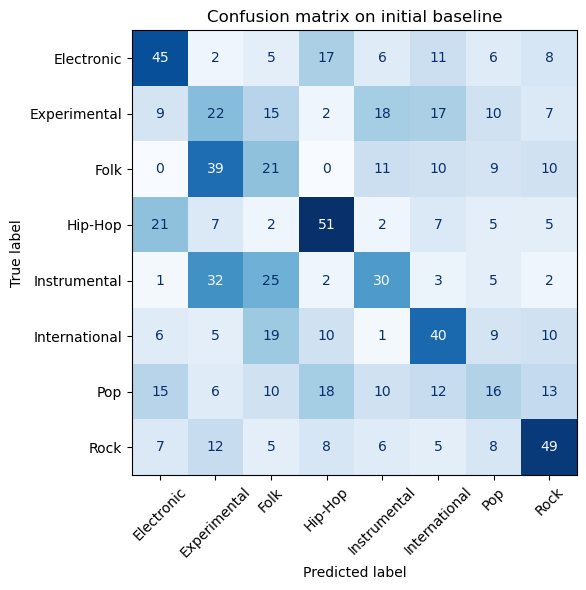

In [18]:
labels = np.unique(y_test)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion matrix on initial baseline")
plt.tight_layout()
plt.show()